In [803]:
# import modules
import pandas as pd # for data analysis
import numpy as np # for numeric functions
import matplotlib.pyplot as plt # for plotting

In [804]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [805]:
#read data from drive
btc_data = pd.read_csv("/content/ETH_training_data_2023-01-01_to_2023-10-31.csv")

In [806]:
import pandas as pd

# Convert the 'date' column to datetime format with the correct format string
btc_data['date'] = pd.to_datetime(btc_data['date'], format='%Y-%m-%d %H:%M:%S')

# Reset the index if necessary
btc_data.reset_index(drop=True, inplace=True)

# Display the first few rows
print(btc_data)




                 unix                date   symbol     open     high      low  \
0       1672531200000 2023-01-01 00:00:00  ETHUSDT  1196.13  1196.14  1195.92   
1       1672531260000 2023-01-01 00:01:00  ETHUSDT  1196.13  1196.25  1196.08   
2       1672531320000 2023-01-01 00:02:00  ETHUSDT  1196.09  1196.10  1195.85   
3       1672531380000 2023-01-01 00:03:00  ETHUSDT  1195.85  1195.86  1195.82   
4       1672531440000 2023-01-01 00:04:00  ETHUSDT  1195.82  1196.32  1195.65   
...               ...                 ...      ...      ...      ...      ...   
226076  1698364560000 2023-10-26 23:56:00  ETHUSDT  1803.70  1804.01  1803.16   
226077  1698364620000 2023-10-26 23:57:00  ETHUSDT  1803.16  1803.81  1803.16   
226078  1698364680000 2023-10-26 23:58:00  ETHUSDT  1803.81  1803.81  1803.11   
226079  1698364740000 2023-10-26 23:59:00  ETHUSDT  1803.12  1803.80  1803.11   
226080  1698710400000 2023-10-31 00:00:00  ETHUSDT  1809.03  1809.34  1808.97   

          close    volume  

In [807]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Convert 'date' column to datetime format
btc_data['date'] = pd.to_datetime(btc_data['date'], format='%Y-%m-%d %H:%M:%S')

# Sort data by date to maintain chronological order
btc_data = btc_data.sort_values(by='date').reset_index(drop=True)

# Split the dataset into training and holdout sets using 80/20 split
train_size = 0.8  # Adjust to 0.7 for 70/30 split or any other ratio
btc_data, btc_hold = train_test_split(btc_data, train_size=train_size, shuffle=False)

# Reset indices to keep things clean
btc_data.reset_index(drop=True, inplace=True)
btc_hold.reset_index(drop=True, inplace=True)

# Display basic info
print("Train Set (btc_data):\n", btc_data.head())
print("\nTest Set (btc_hold):\n", btc_hold.head())

# Save the split datasets to CSV (optional)
btc_data.to_csv('btc_data_train.csv', index=False)  # Saving train set as btc_data_train.csv
btc_hold.to_csv('btc_data_hold.csv', index=False)   # Saving test set as btc_data_hold.csv

# Verification step
print(f"Train Dataset Size (btc_data): {len(btc_data)} rows")
print(f"Test Dataset Size (btc_hold): {len(btc_hold)} rows")
print(f"Train Dataset Range: {btc_data['date'].min()} to {btc_data['date'].max()}")
print(f"Test Dataset Range: {btc_hold['date'].min()} to {btc_hold['date'].max()}")


Train Set (btc_data):
             unix                date   symbol     open     high      low  \
0  1672531200000 2023-01-01 00:00:00  ETHUSDT  1196.13  1196.14  1195.92   
1  1672531260000 2023-01-01 00:01:00  ETHUSDT  1196.13  1196.25  1196.08   
2  1672531320000 2023-01-01 00:02:00  ETHUSDT  1196.09  1196.10  1195.85   
3  1672531380000 2023-01-01 00:03:00  ETHUSDT  1195.85  1195.86  1195.82   
4  1672531440000 2023-01-01 00:04:00  ETHUSDT  1195.82  1196.32  1195.65   

     close    volume    volume_from  marketorder_volume  \
0  1196.13   65.5003   78336.933825             20.5552   
1  1196.09   61.1703   73172.254498              6.0606   
2  1195.85   32.9332   39389.839241              8.7272   
3  1195.82   56.8456   67978.442332              5.7935   
4  1196.32  118.1098  141237.845266             82.1776   

   marketorder_volume_from  tradecount  year             datetime  
0             24584.544571         170  2023  2023-01-01 00:00:00  
1              7249.354624   

In [808]:
# Rename the columns to match the original format
btc_data.rename(columns={
    'Timestamp': 'date',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume'
}, inplace=True)

# Display data types to confirm
print(btc_data.dtypes)


unix                                int64
date                       datetime64[ns]
symbol                             object
open                              float64
high                              float64
low                               float64
close                             float64
volume                            float64
volume_from                       float64
marketorder_volume                float64
marketorder_volume_from           float64
tradecount                          int64
year                                int64
datetime                           object
dtype: object


In [809]:
# Check for missing values in both datasets
print("\nMissing Values in BTC Dataset:")
print(btc_data.isnull().sum())


Missing Values in BTC Dataset:
unix                       0
date                       0
symbol                     0
open                       0
high                       0
low                        0
close                      0
volume                     0
volume_from                0
marketorder_volume         0
marketorder_volume_from    0
tradecount                 0
year                       0
datetime                   0
dtype: int64


In [810]:
# Remove rows with null values
btc_data_clean = btc_data.dropna()

# Check if null values are removed
print(btc_data_clean.isnull().sum())

# Optionally, check the shape of the cleaned DataFrame
print(btc_data_clean.shape)


unix                       0
date                       0
symbol                     0
open                       0
high                       0
low                        0
close                      0
volume                     0
volume_from                0
marketorder_volume         0
marketorder_volume_from    0
tradecount                 0
year                       0
datetime                   0
dtype: int64
(180864, 14)


In [811]:
btc_data

,unix,date,symbol,open,high,low,close,volume,volume_from,marketorder_volume,marketorder_volume_from,tradecount,year,datetime
0,1672531200000,2023-01-01 00:00:00,ETHUSDT,1196.13,1196.14,1195.92,1196.13,65.5003,7.833693e+04,20.5552,2.458454e+04,170,2023,2023-01-01 00:00:00
1,1672531260000,2023-01-01 00:01:00,ETHUSDT,1196.13,1196.25,1196.08,1196.09,61.1703,7.317225e+04,6.0606,7.249355e+03,297,2023,2023-01-01 00:01:00
2,1672531320000,2023-01-01 00:02:00,ETHUSDT,1196.09,1196.10,1195.85,1195.85,32.9332,3.938984e+04,8.7272,1.043808e+04,230,2023,2023-01-01 00:02:00
3,1672531380000,2023-01-01 00:03:00,ETHUSDT,1195.85,1195.86,1195.82,1195.82,56.8456,6.797844e+04,5.7935,6.928151e+03,168,2023,2023-01-01 00:03:00
4,1672531440000,2023-01-01 00:04:00,ETHUSDT,1195.82,1196.32,1195.65,1196.32,118.1098,1.412378e+05,82.1776,9.827186e+04,337,2023,2023-01-01 00:04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180859,1690553940000,2023-07-28 14:19:00,ETHUSDT,1876.16,1876.60,1876.02,1876.60,368.2037,6.908799e+05,221.8632,4.162749e+05,292,2023,2023-07-28 14:19:00
180860,1690554000000,2023-07-28 14:20:00,ETHUSDT,1876.60,1878.80,1876.40,1877.80,766.9256,1.439871e+06,437.5945,8.216161e+05,893,2023,2023-07-28 14:20:00
180861,1690554060000,2023-07-28 14:21:00,ETHUSDT,1877.80,1879.61,1877.62,1879.56,900.5948,1.692061e+06,645.2509,1.212312e+06,787,2023,2023-07-28 14:21:00
180862,1690554120000,2023-07-28 14:22:00,ETHUSDT,1879.55,1879.83,1878.42,1878.67,373.7725,7.024433e+05,157.6085,2.961812e+05,430,2023,2023-07-28 14:22:00


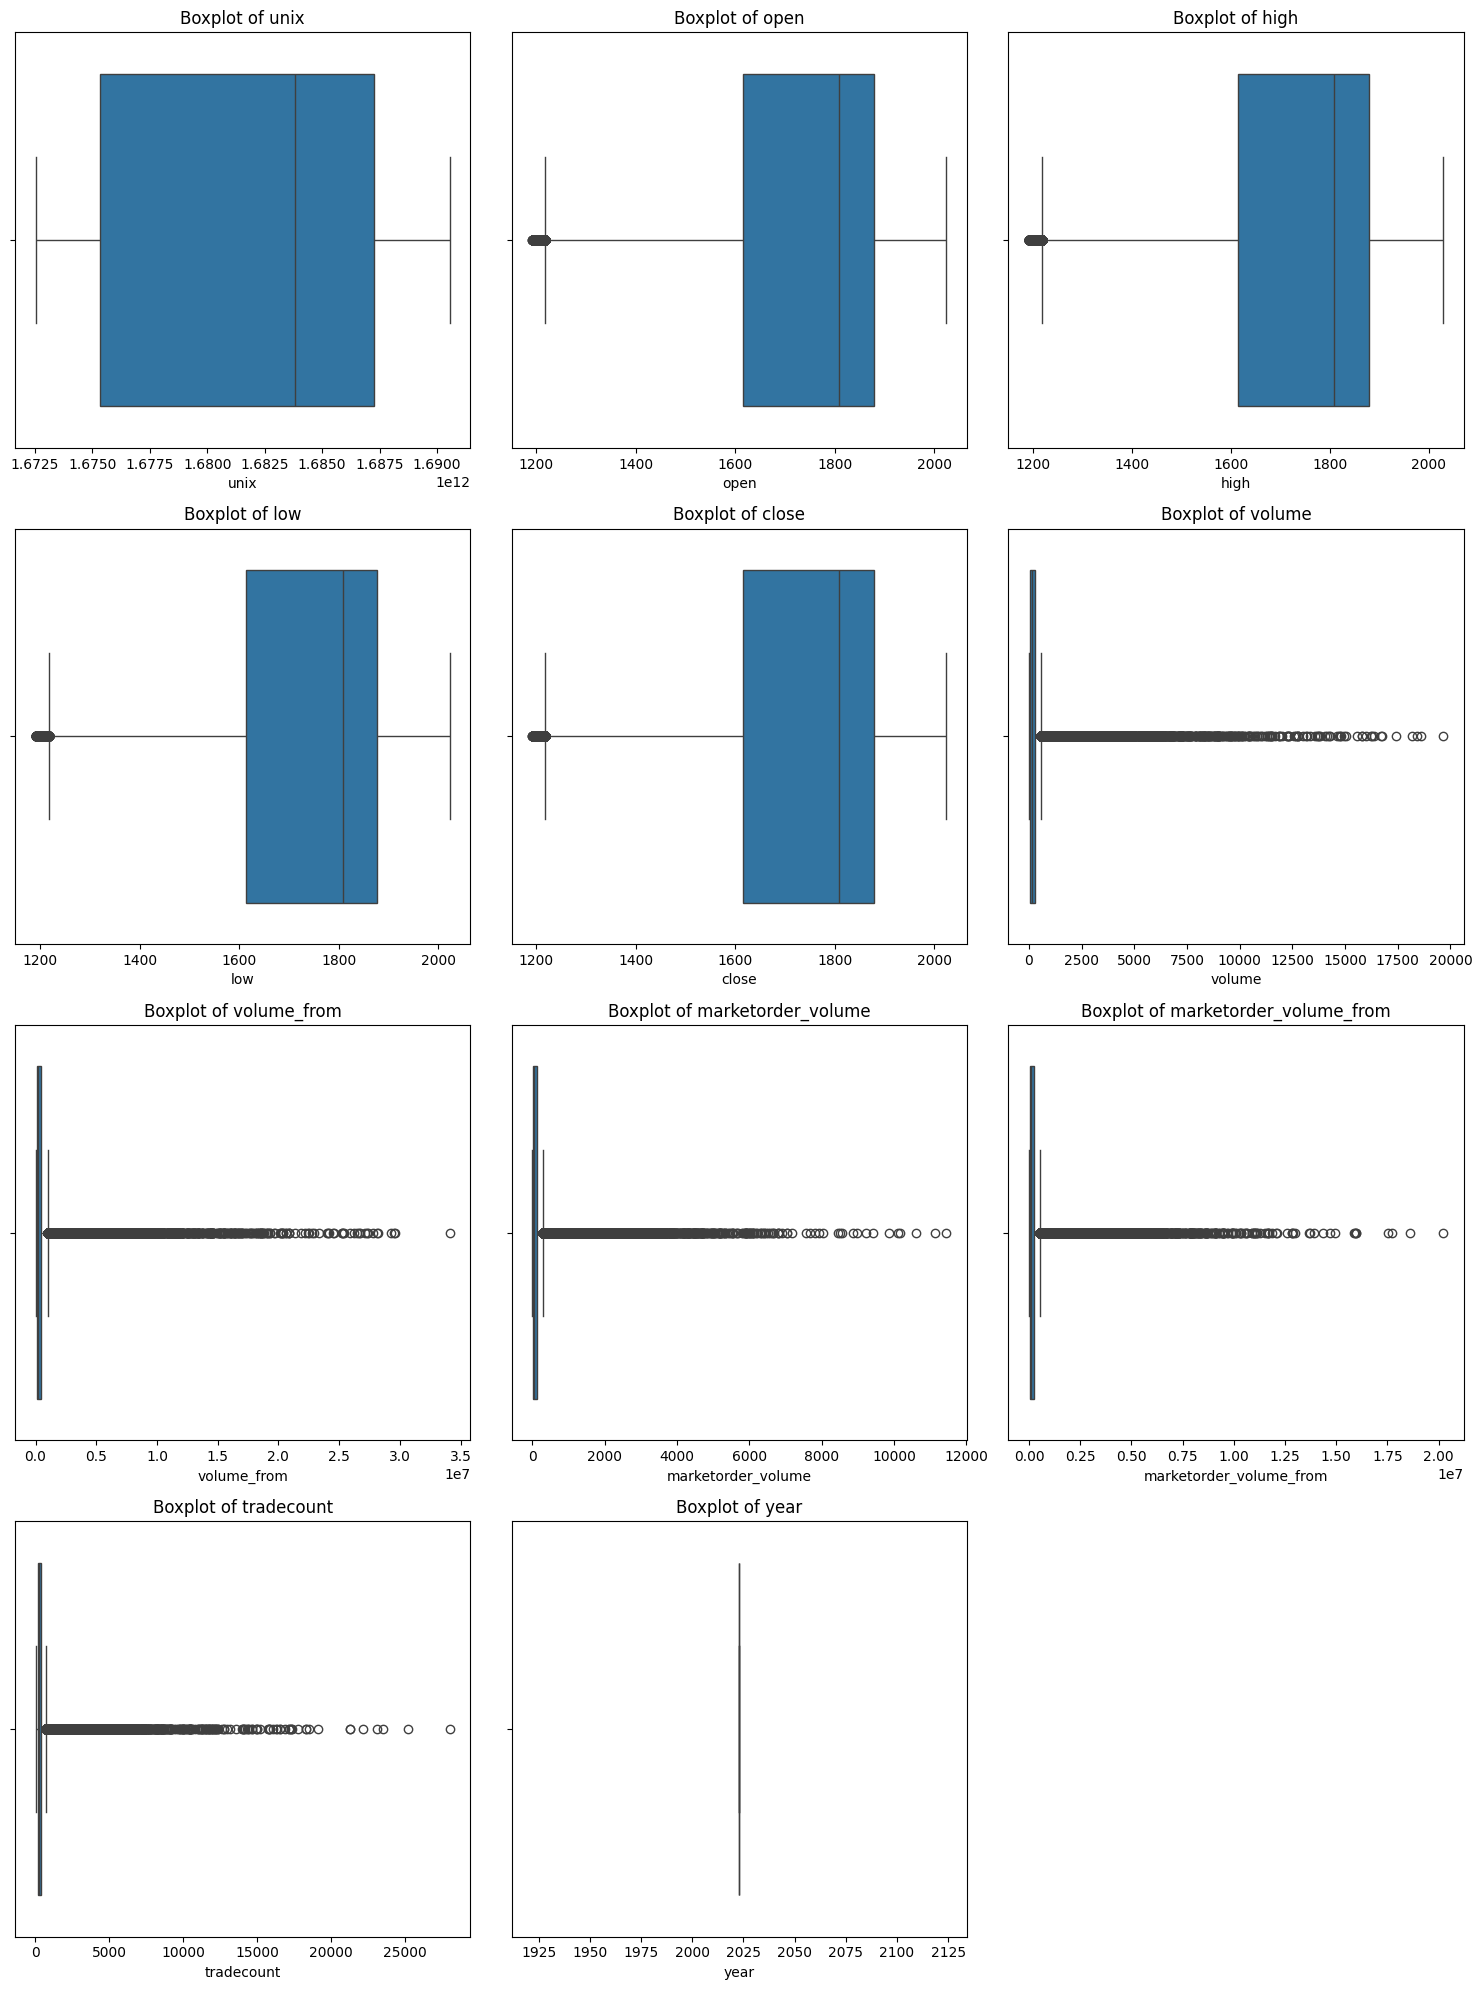

In [812]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get all numeric columns automatically
numeric_columns = btc_data.select_dtypes(include='number').columns

# Set up the grid size dynamically based on the number of numeric columns
num_cols = len(numeric_columns)
num_rows = math.ceil(num_cols / 3)  # Adjust the number of rows needed

# Plot boxplots for the numeric columns to check for outliers
plt.figure(figsize=(15, 5 * num_rows))  # Adjust height dynamically based on the number of rows

# Plotting boxplots for all numeric colupmns in the dataset
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(num_rows, 3, i)  # Use dynamic rows and columns
    sns.boxplot(data=btc_data, x=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [813]:
import pandas as pd
import numpy as np

# Function to calculate Simple Moving Average (SMA)
def SMA(data, window):
    return data.rolling(window=window).mean()

# Function to calculate Relative Strength Index (RSI)
def RSI(data, window=14):
    delta = data.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Function to calculate Moving Average Convergence Divergence (MACD)
def MACD(data, fast_period=12, slow_period=26, signal_period=9):
    fast_ema = data.ewm(span=fast_period, adjust=False).mean()
    slow_ema = data.ewm(span=slow_period, adjust=False).mean()
    macd = fast_ema - slow_ema
    signal = macd.ewm(span=signal_period, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

# Function to calculate Bollinger Bands
def BollingerBands(data, window=20, num_std=2):
    sma = data.rolling(window=window).mean()
    std = data.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, sma, lower_band

# Function to calculate On-Balance Volume (OBV)
def calculate_obv(data):
    obv = [0]  # Initialize OBV with the first value as 0
    for i in range(1, len(data)):
        if data['close'].iloc[i] > data['close'].iloc[i - 1]:
            obv.append(obv[-1] + data['volume'].iloc[i])
        elif data['close'].iloc[i] < data['close'].iloc[i - 1]:
            obv.append(obv[-1] - data['volume'].iloc[i])
        else:
            obv.append(obv[-1])
    return obv

# Function to add technical indicators to the dataset
def add_manual_technical_indicators(data):
    # SMA Indicators
    data['SMA_short'] = SMA(data['close'], window=20)  # Short-term SMA
    data['SMA_long'] = SMA(data['close'], window=50)   # Long-term SMA

    # RSI Indicator
    data['RSI'] = RSI(data['close'], window=14)

    # MACD Indicators
    data['MACD'], data['MACD_signal'], data['MACD_hist'] = MACD(
        data['close'], fast_period=12, slow_period=26, signal_period=9
    )

    # Bollinger Bands
    data['BB_upper'], data['BB_middle'], data['BB_lower'] = BollingerBands(
        data['close'], window=20, num_std=2
    )

    # OBV Indicator
    data['OBV'] = calculate_obv(data)

    # Drop rows with missing values due to rolling calculations
    #data.dropna(inplace=True)

    return data

# Apply the manual calculations to btc_data
btc_data = add_manual_technical_indicators(btc_data)

# Verifying the calculations
print("\nBTC Data Sample with Indicators:")
print(btc_data[['close', 'SMA_short', 'SMA_long', 'RSI', 'MACD', 'OBV', 'BB_upper', 'BB_middle', 'BB_lower']].tail(10))



BTC Data Sample with Indicators:
          close  SMA_short   SMA_long        RSI      MACD          OBV  \
180854  1875.62  1872.6145  1871.0134  74.242424  1.192511 -362701.8764   
180855  1875.28  1872.8305  1871.1290  69.955817  1.227947 -363240.6688   
180856  1875.93  1873.0755  1871.2512  71.627260  1.293569 -363101.2717   
180857  1876.00  1873.3085  1871.3648  85.855263  1.335825 -362955.6993   
180858  1876.15  1873.5375  1871.4972  86.151369  1.365673 -362695.7039   
180859  1876.60  1873.8210  1871.6296  88.012140  1.409394 -362327.5002   
180860  1877.80  1874.0900  1871.7968  89.410188  1.523312 -361560.5746   
180861  1879.56  1874.4395  1871.9880  93.046358  1.735604 -360659.9798   
180862  1878.67  1874.7320  1872.1594  84.473953  1.811153 -361033.7523   
180863  1878.15  1875.0575  1872.3108  79.098361  1.808223 -361466.3325   

           BB_upper  BB_middle     BB_lower  
180854  1875.800353  1872.6145  1869.428647  
180855  1876.127877  1872.8305  1869.533123  
18

In [814]:
# Function to calculate the Stochastic Oscillator
def stochastic_oscillator(data, window=14):
    low_min = data['low'].rolling(window=window).min()
    high_max = data['high'].rolling(window=window).max()
    stoch_k = 100 * ((data['close'] - low_min) / (high_max - low_min))
    return stoch_k

# Add Stochastic Oscillator to the 15-minute dataset
btc_data['stoch_k'] = stochastic_oscillator(btc_data)


In [815]:
# Function to calculate VWAP
def vwap(data):
    return (data['volume'] * data['close']).cumsum() / data['volume'].cumsum()

# Add VWAP to the 15-minute dataset
btc_data['VWAP'] = vwap(btc_data)


In [816]:
# Function to calculate Fibonacci Retracement levels
def fibonacci_retracement(data):
    high = data['high'].max()
    low = data['low'].min()
    diff = high - low
    return {
        'fib_23.6': high - diff * 0.236,
        'fib_38.2': high - diff * 0.382,
        'fib_50': high - diff * 0.5,
        'fib_61.8': high - diff * 0.618,
        'fib_100': low
    }

# Add Fibonacci retracement levels to the dataset
fib_levels = fibonacci_retracement(btc_data)
for level, value in fib_levels.items():
    btc_data[level] = value


In [817]:
btc_data.columns

Index(['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'volume_from', 'marketorder_volume', 'marketorder_volume_from',
       'tradecount', 'year', 'datetime', 'SMA_short', 'SMA_long', 'RSI',
       'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_middle', 'BB_lower',
       'OBV', 'stoch_k', 'VWAP', 'fib_23.6', 'fib_38.2', 'fib_50', 'fib_61.8',
       'fib_100'],
      dtype='object')

In [818]:
# Ensure the 'date' column is in datetime format
btc_data['date'] = pd.to_datetime(btc_data['date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Add a 15-minute floor to define trade windows
btc_data['trade_window'] = btc_data['date'].dt.floor('15T')  # Use the 'date' column to define trade windows

# Set 'date' as the index while retaining it as a column
btc_data.set_index('date', inplace=True, drop=False)

# Verify the changes
print(btc_data.head())
print("\nIndex type:", type(btc_data.index))  # Should confirm it's a DatetimeIndex


                              unix                date   symbol     open  \
date                                                                       
2023-01-01 00:49:00  1672534140000 2023-01-01 00:49:00  ETHUSDT  1194.92   
2023-01-01 00:50:00  1672534200000 2023-01-01 00:50:00  ETHUSDT  1194.65   
2023-01-01 00:51:00  1672534260000 2023-01-01 00:51:00  ETHUSDT  1194.19   
2023-01-01 00:52:00  1672534320000 2023-01-01 00:52:00  ETHUSDT  1194.20   
2023-01-01 00:53:00  1672534380000 2023-01-01 00:53:00  ETHUSDT  1194.48   

                        high      low    close    volume    volume_from  \
date                                                                      
2023-01-01 00:49:00  1194.93  1194.64  1194.64   72.6362   86787.267220   
2023-01-01 00:50:00  1194.65  1194.19  1194.19  179.2556  214121.077365   
2023-01-01 00:51:00  1194.20  1194.19  1194.19   73.6349   87934.651098   
2023-01-01 00:52:00  1194.49  1194.19  1194.48   11.1299   13291.841966   
2023-01-01 00:53:

<ipython-input-818-984ef8dbdf91>:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  btc_data['trade_window'] = btc_data['date'].dt.floor('15T')  # Use the 'date' column to define trade windows


In [819]:
import pandas as pd

# Ensure the timestamp is in datetime format
btc_data['timestamp'] = pd.to_datetime(btc_data['date'])

# Generate 15-minute windows
btc_data['15_min_window'] = btc_data['timestamp'].dt.floor('15T')

# Handle missing minutes by only considering available data in each 15-minute window
# Create a unique ID for each 15-minute window
btc_data['15_min_window_id'] = btc_data['15_min_window'].rank(method='dense').astype(int)

# Debugging: Ensure the 15-minute windows are created correctly
print(f"Total 15-minute windows: {btc_data['15_min_window'].nunique()}")
print(btc_data[['timestamp', '15_min_window', '15_min_window_id']].head(40))


Total 15-minute windows: 12055
                              timestamp       15_min_window  15_min_window_id
date                                                                         
2023-01-01 00:49:00 2023-01-01 00:49:00 2023-01-01 00:45:00                 1
2023-01-01 00:50:00 2023-01-01 00:50:00 2023-01-01 00:45:00                 1
2023-01-01 00:51:00 2023-01-01 00:51:00 2023-01-01 00:45:00                 1
2023-01-01 00:52:00 2023-01-01 00:52:00 2023-01-01 00:45:00                 1
2023-01-01 00:53:00 2023-01-01 00:53:00 2023-01-01 00:45:00                 1
2023-01-01 00:54:00 2023-01-01 00:54:00 2023-01-01 00:45:00                 1
2023-01-01 00:55:00 2023-01-01 00:55:00 2023-01-01 00:45:00                 1
2023-01-01 00:56:00 2023-01-01 00:56:00 2023-01-01 00:45:00                 1
2023-01-01 00:57:00 2023-01-01 00:57:00 2023-01-01 00:45:00                 1
2023-01-01 00:58:00 2023-01-01 00:58:00 2023-01-01 00:45:00                 1
2023-01-01 00:59:00 2023-01-01 00

<ipython-input-819-05f73b22df92>:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  btc_data['15_min_window'] = btc_data['timestamp'].dt.floor('15T')


In [820]:
btc_data

,unix,date,symbol,open,high,low,close,volume,volume_from,marketorder_volume,...,VWAP,fib_23.6,fib_38.2,fib_50,fib_61.8,fib_100,trade_window,timestamp,15_min_window,15_min_window_id
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:49:00,1672534140000,2023-01-01 00:49:00,ETHUSDT,1194.92,1194.93,1194.64,1194.64,72.6362,8.678727e+04,16.5358,...,1194.640000,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-01-01 00:45:00,2023-01-01 00:49:00,2023-01-01 00:45:00,1
2023-01-01 00:50:00,1672534200000,2023-01-01 00:50:00,ETHUSDT,1194.65,1194.65,1194.19,1194.19,179.2556,2.141211e+05,17.3016,...,1194.319763,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-01-01 00:45:00,2023-01-01 00:50:00,2023-01-01 00:45:00,1
2023-01-01 00:51:00,1672534260000,2023-01-01 00:51:00,ETHUSDT,1194.19,1194.20,1194.19,1194.19,73.6349,8.793465e+04,58.9867,...,1194.290410,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-01-01 00:45:00,2023-01-01 00:51:00,2023-01-01 00:45:00,1
2023-01-01 00:52:00,1672534320000,2023-01-01 00:52:00,ETHUSDT,1194.20,1194.49,1194.19,1194.48,11.1299,1.329184e+04,9.6854,...,1194.296678,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-01-01 00:45:00,2023-01-01 00:52:00,2023-01-01 00:45:00,1
2023-01-01 00:53:00,1672534380000,2023-01-01 00:53:00,ETHUSDT,1194.48,1194.58,1194.48,1194.58,38.4406,4.591706e+04,21.6915,...,1194.325714,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-01-01 00:45:00,2023-01-01 00:53:00,2023-01-01 00:45:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-28 14:19:00,1690553940000,2023-07-28 14:19:00,ETHUSDT,1876.16,1876.60,1876.02,1876.60,368.2037,6.908799e+05,221.8632,...,1711.951384,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-07-28 14:15:00,2023-07-28 14:19:00,2023-07-28 14:15:00,12055
2023-07-28 14:20:00,1690554000000,2023-07-28 14:20:00,ETHUSDT,1876.60,1878.80,1876.40,1877.80,766.9256,1.439871e+06,437.5945,...,1711.953998,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-07-28 14:15:00,2023-07-28 14:20:00,2023-07-28 14:15:00,12055
2023-07-28 14:21:00,1690554060000,2023-07-28 14:21:00,ETHUSDT,1877.80,1879.61,1877.62,1879.56,900.5948,1.692061e+06,645.2509,...,1711.957100,1831.21456,1708.78772,1609.84,1510.89228,1190.57,2023-07-28 14:15:00,2023-07-28 14:21:00,2023-07-28 14:15:00,12055


In [821]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set initial parameters
initial_investment = 10000
transaction_fee = 0.002  # 0.2% transaction fee per trade
stop_loss_multiplier = 1.5  # ATR multiplier for stop-loss
take_profit_multiplier = 2.0  # ATR multiplier for take-profit
max_drawdown_limit = 0.2  # 20% maximum drawdown
min_portfolio_value = initial_investment * (1 - max_drawdown_limit)  # $8,000 minimum

# Function to calculate ATR (Average True Range)
def ATR(data, window=14):
    high_low = data['high'] - data['low']
    high_close = np.abs(data['high'] - data['close'].shift())
    low_close = np.abs(data['low'] - data['close'].shift())
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return true_range.rolling(window=window, min_periods=1).mean()

# Function to calculate RSI (Relative Strength Index)
def RSI(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Function to calculate SMA (Simple Moving Average)
def SMA(data, window):
    return data.rolling(window=window).mean()

# Add 15-minute window index
btc_data['timestamp'] = pd.to_datetime(btc_data['date'])
btc_data['15min_window'] = btc_data['timestamp'].dt.floor('15T')

# Add ATR to the dataset
btc_data['ATR'] = ATR(btc_data, window=14)

# Add SMA and RSI to the dataset
btc_data['SMA_short'] = SMA(btc_data['close'], window=7)
btc_data['SMA_long'] = SMA(btc_data['close'], window=21)
btc_data['RSI'] = RSI(btc_data['close'], window=14)

# Define buy and sell signals
btc_data['buy_signal'] = (btc_data['SMA_short'] > btc_data['SMA_long']) & (btc_data['RSI'] < 30)  # Adjusted for fewer signals
btc_data['sell_signal'] = (btc_data['SMA_short'] < btc_data['SMA_long']) & (btc_data['RSI'] > 70)

# Trading Logic: Generate final signals for each 15-minute window
def calculate_signals(group):
    signal = np.zeros(len(group))  # Initialize signal array
    position_open = False
    entry_price = None
    portfolio_value = initial_investment

    for i in range(len(group)):
        # Check if portfolio value drops below the allowed minimum
        if portfolio_value < min_portfolio_value:
            signal[i] = -1  # Force sell to stop losses
            position_open = False
            entry_price = None
            break

        # Buy condition
        if group['buy_signal'].iloc[i] and not position_open:
            signal[i] = 1
            position_open = True
            entry_price = group['close'].iloc[i]

        # Manage open position
        elif position_open:
            # Stop-loss condition
            if group['close'].iloc[i] <= entry_price - (group['ATR'].iloc[i] * stop_loss_multiplier):
                signal[i] = -1
                position_open = False
                entry_price = None

            # Take-profit condition
            elif group['close'].iloc[i] >= entry_price + (group['ATR'].iloc[i] * take_profit_multiplier):
                signal[i] = -1
                position_open = False
                entry_price = None

            # Sell signal condition
            elif group['sell_signal'].iloc[i]:
                signal[i] = -1
                position_open = False
                entry_price = None

    if position_open:
        signal[-1] = -1  # Force sell if position is still open at the end of the window

    return pd.Series(signal, index=group.index)

btc_data['final_signal'] = btc_data.groupby('15min_window').apply(calculate_signals).reset_index(level=0, drop=True)

# Calculate returns and portfolio value
btc_data['returns'] = btc_data['close'].pct_change()
btc_data['strategy_returns'] = btc_data['returns'] * btc_data['final_signal'].shift(1) - transaction_fee * np.abs(btc_data['final_signal'].shift(1))
btc_data['portfolio_value'] = initial_investment * (1 + btc_data['strategy_returns']).cumprod()
btc_data['portfolio_value'] = btc_data['portfolio_value'].apply(lambda x: max(x, min_portfolio_value))

<ipython-input-821-53389c90c1f5>:35: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  btc_data['15min_window'] = btc_data['timestamp'].dt.floor('15T')
<ipython-input-821-53389c90c1f5>:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  btc_data['final_signal'] = btc_data.groupby('15min_window').apply(calculate_signals).reset_index(level=0, drop=True)


Buy Signals: 181
Sell Signals: 336
Annualized Return: -32.33%
Annualized Volatility: 0.37%
Sharpe Ratio: -88.00
Max Drawdown: 20.00%
Buy and Hold Annualized Return (after transaction costs): 120.34%


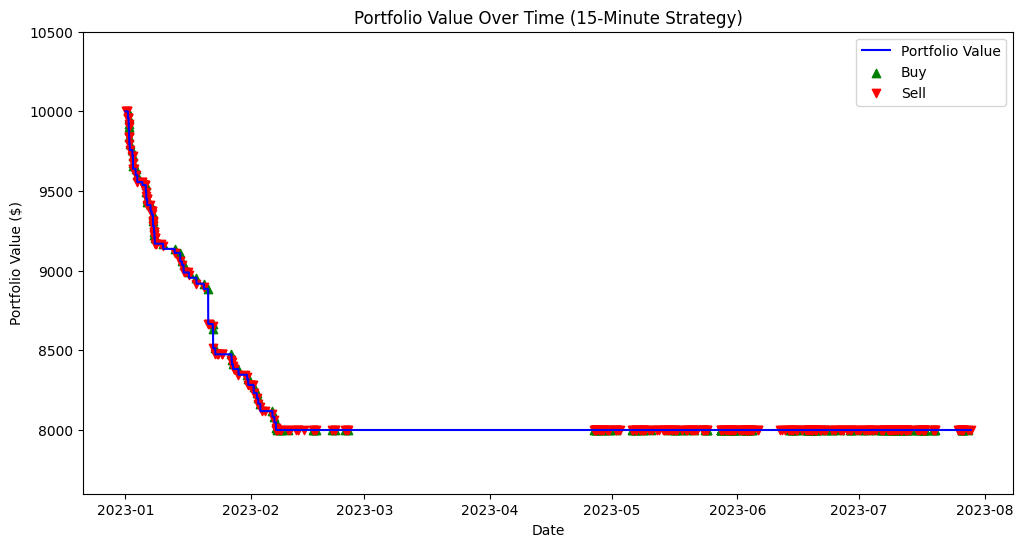

In [823]:
import matplotlib.pyplot as plt

# Debugging: Check final_signal counts
print("Buy Signals:", btc_data[btc_data['final_signal'] == 1].shape[0])
print("Sell Signals:", btc_data[btc_data['final_signal'] == -1].shape[0])

# Function to calculate performance metrics based on trade-specific windows
def generate_performance_metrics(data, initial_investment):
    # Filter data for trades (final_signal != 0)
    trade_data = data[data['final_signal'] != 0].copy()

    # Ensure at least one trade exists
    if trade_data.empty:
        print("No valid trades found. Ensure signals are generated.")
        return {
            'annualized_return': 0,
            'annualized_volatility': 0,
            'sharpe_ratio': 0,
            'max_drawdown': 0,
            'buy_hold_annualized_return': 0
        }

    # Calculate total return for active trades
    total_return = (data['portfolio_value'].iloc[-1] - initial_investment) / initial_investment

    # Determine the dataset duration (in days)
    dataset_duration_seconds = (data['timestamp'].iloc[-1] - data['timestamp'].iloc[0]).total_seconds()
    dataset_duration_days = dataset_duration_seconds / (24 * 60 * 60)

    # Calculate strategy returns
    trade_returns = trade_data['strategy_returns']

    # Calculate annualized volatility
    num_15min_intervals_per_day = 24 * 4  # 15-minute intervals in a day
    observed_intervals = len(trade_data)  # Actual 15-minute intervals in the dataset
    scaling_factor = np.sqrt(num_15min_intervals_per_day * dataset_duration_days / observed_intervals)
    annualized_volatility = trade_returns.std() * scaling_factor

    # Calculate annualized return
    annualized_return = (1 + total_return) ** (365 / dataset_duration_days) - 1

    # Sharpe Ratio
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0

    # Max Drawdown
    trade_data['drawdown'] = (trade_data['portfolio_value'].cummax() - trade_data['portfolio_value']) / trade_data['portfolio_value'].cummax()
    max_drawdown = trade_data['drawdown'].max()

    # Buy-and-hold comparison
    buy_hold_return = (data['close'].iloc[-1] - data['close'].iloc[0]) / data['close'].iloc[0]
    buy_hold_annualized_return = (1 + buy_hold_return) ** (365 / dataset_duration_days) - 1
    buy_hold_transaction_costs = 2 * transaction_fee

    return {
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'buy_hold_annualized_return': buy_hold_annualized_return - buy_hold_transaction_costs
    }

# Ensure timestamp is in datetime format
btc_data['timestamp'] = pd.to_datetime(btc_data['timestamp'])

# Generate performance metrics
metrics = generate_performance_metrics(btc_data, initial_investment)

# Print performance metrics
print("Annualized Return: {:.2%}".format(metrics['annualized_return']))
print("Annualized Volatility: {:.2%}".format(metrics['annualized_volatility']))
print("Sharpe Ratio: {:.2f}".format(metrics['sharpe_ratio']))
print("Max Drawdown: {:.2%}".format(metrics['max_drawdown']))
print("Buy and Hold Annualized Return (after transaction costs): {:.2%}".format(metrics['buy_hold_annualized_return']))

# Plot Portfolio Value over Time
plt.figure(figsize=(12, 6))
plt.plot(btc_data['timestamp'], btc_data['portfolio_value'], label='Portfolio Value', color='blue')

# Mark buy and sell signals on the graph
buy_signals = btc_data[btc_data['final_signal'] == 1]
sell_signals = btc_data[btc_data['final_signal'] == -1]
plt.scatter(buy_signals['timestamp'], buy_signals['portfolio_value'], color='green', marker='^', label='Buy', alpha=1)
plt.scatter(sell_signals['timestamp'], sell_signals['portfolio_value'], color='red', marker='v', label='Sell', alpha=1)

# Adjust y-axis dynamically
plt.ylim(btc_data['portfolio_value'].min() * 0.95, btc_data['portfolio_value'].max() * 1.05)

# Set labels and title
plt.title('Portfolio Value Over Time (15-Minute Strategy)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()
